In [1]:
import numpy as np

# Change the filenames to EXACTLY match your files
closed_filename = 'Alpha_EEG.txt'
open_filename = 'Open_EEG.txt'

sampling_freq = 400

# Define column names
columns = ['time', 'recording']

# Use numpy genfromtxt to import both files
closed_data = np.genfromtxt(closed_filename, dtype=float, usecols=(0,1), skip_header=6, delimiter='\t', names=columns, encoding = 'unicode_escape')
open_data = np.genfromtxt(open_filename, dtype=float, usecols=(0,1), skip_header=6, delimiter='\t', names=columns, encoding = 'unicode_escape')

# Define a function to remove nan values
def nan_helper(y):
    return np.isnan(y), lambda z: z.nonzero()[0]

# Save recording & timestamps as variables
closed_timestamps = closed_data['time']
closed_recording = closed_data['recording']
nans, x = nan_helper(closed_recording)
closed_recording[nans]= np.interp(x(nans), x(~nans), closed_recording[~nans])

open_timestamps = open_data['time']
open_recording = open_data['recording']
nans, x = nan_helper(open_recording)
open_recording[nans]= np.interp(x(nans), x(~nans), open_recording[~nans])

closed_recording

array([-26.96875, -24.93125, -20.56875, ...,  14.28125,   8.725  ,
         4.675  ], shape=(12300,))

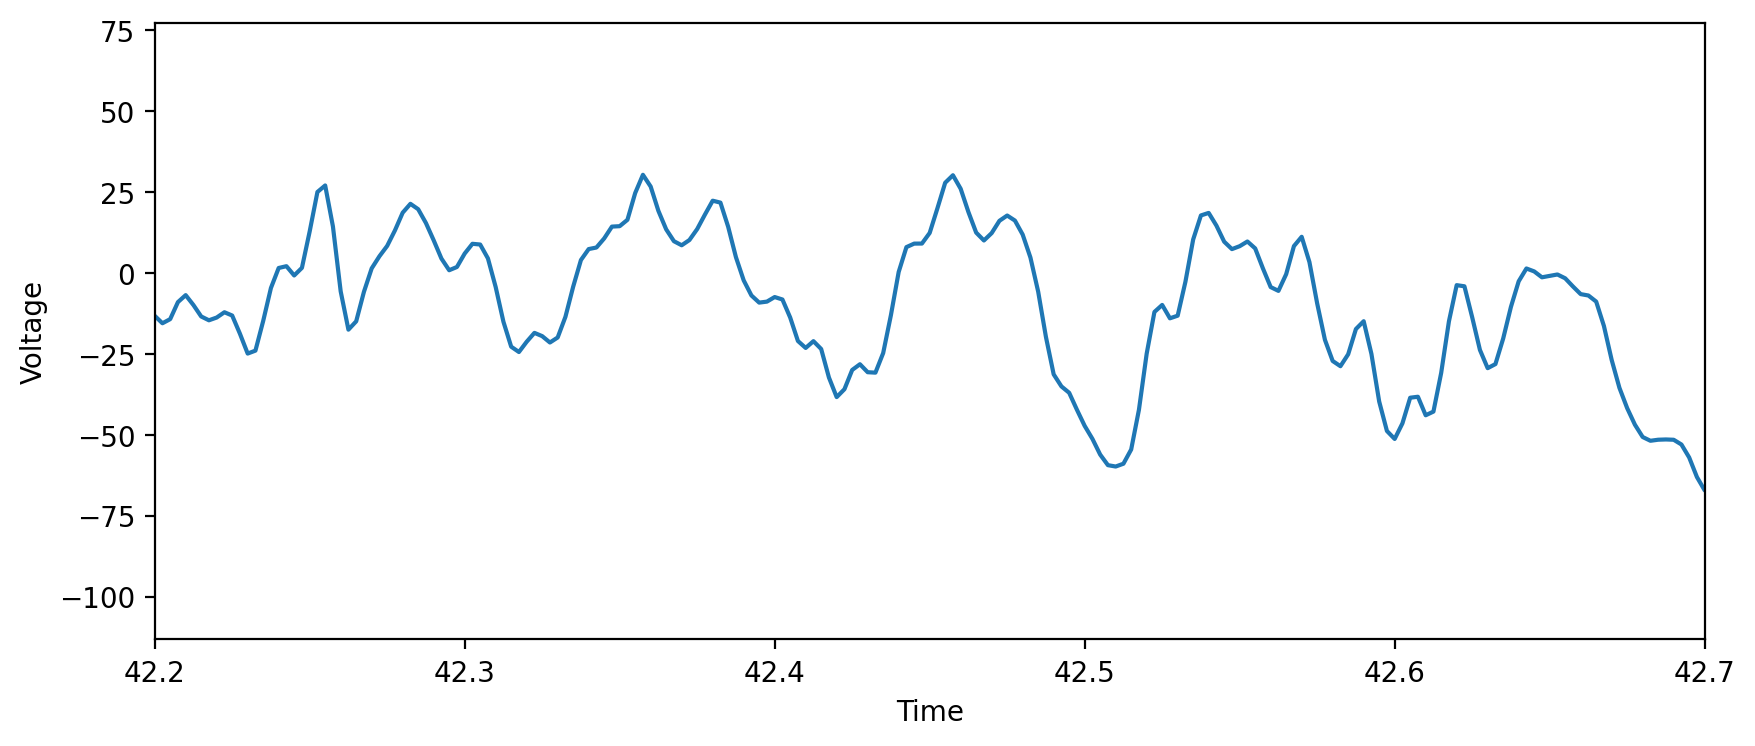

In [32]:
# Import plotting packages
import matplotlib.pyplot as plt
%matplotlib inline 
%config InlineBackend.figure_format = 'retina'

# Set up figure
fig,ax = plt.subplots(figsize=(10,4))

# Change the variables below if you'd like to plot eyes open instead
plt.plot(closed_timestamps,closed_recording)
plt.xlim(42.2, 42.7)

# You may need to change the x label!
plt.xlabel('Time') 

# You may need to change the y label!
plt.ylabel('Voltage')

# You can uncomment the line below to restrict the x axis plotting -- for example, to zoom into alpha waves
#plt.xlim([45,50])

plt.savefig('EEG_signal.png',dpi = 300)

plt.show()

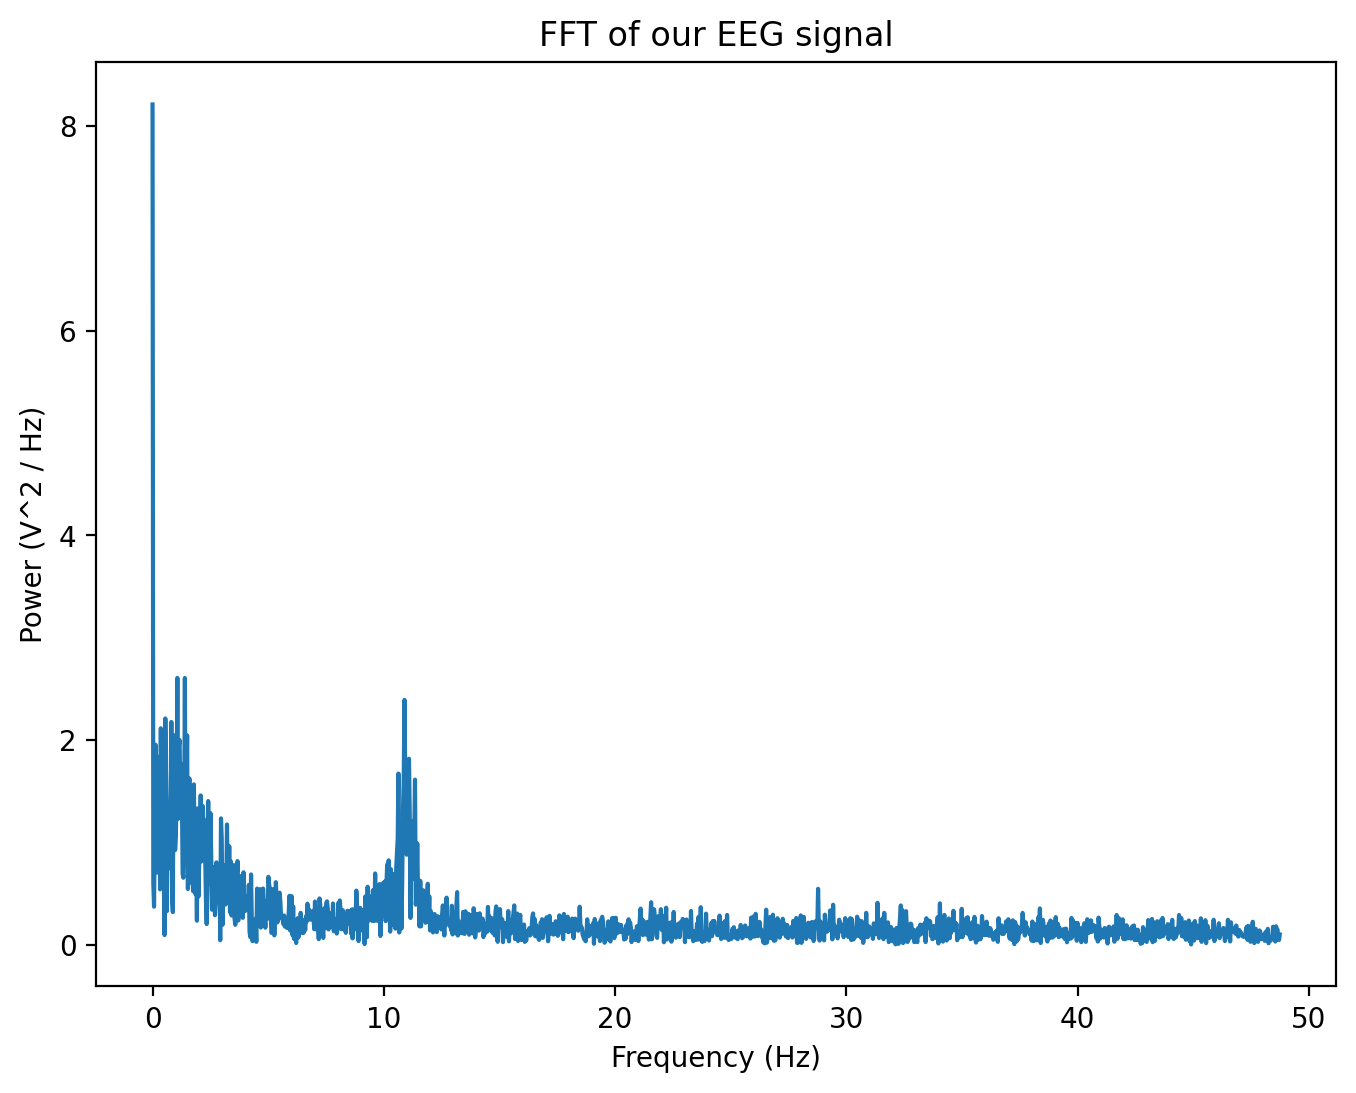

In [7]:
# Calculate the fourier transform of complex signal
ft = np.fft.fft(closed_recording)/len(closed_timestamps) # Compute the fft, normalized by time

# Find frequency values for the x axis
nyq = sampling_freq/2 # Determine the nyquist frequency

# Create freq bins for plotting by creating a vector from 0 to nyquist, with as many points as in fft
fx_bins = np.linspace(0,nyq,int(np.floor(len(closed_recording)/2))+1)

# plotting up to 200 Hz
plt.figure(figsize=(8, 6))
plt.plot(fx_bins[0:1500],abs(ft[0:1500]))
plt.ylabel('Power (V^2 / Hz)')
plt.xlabel('Frequency (Hz)')
plt.title('FFT of our EEG signal')
plt.savefig('fft_EEG.png', dpi =300)
plt.show()

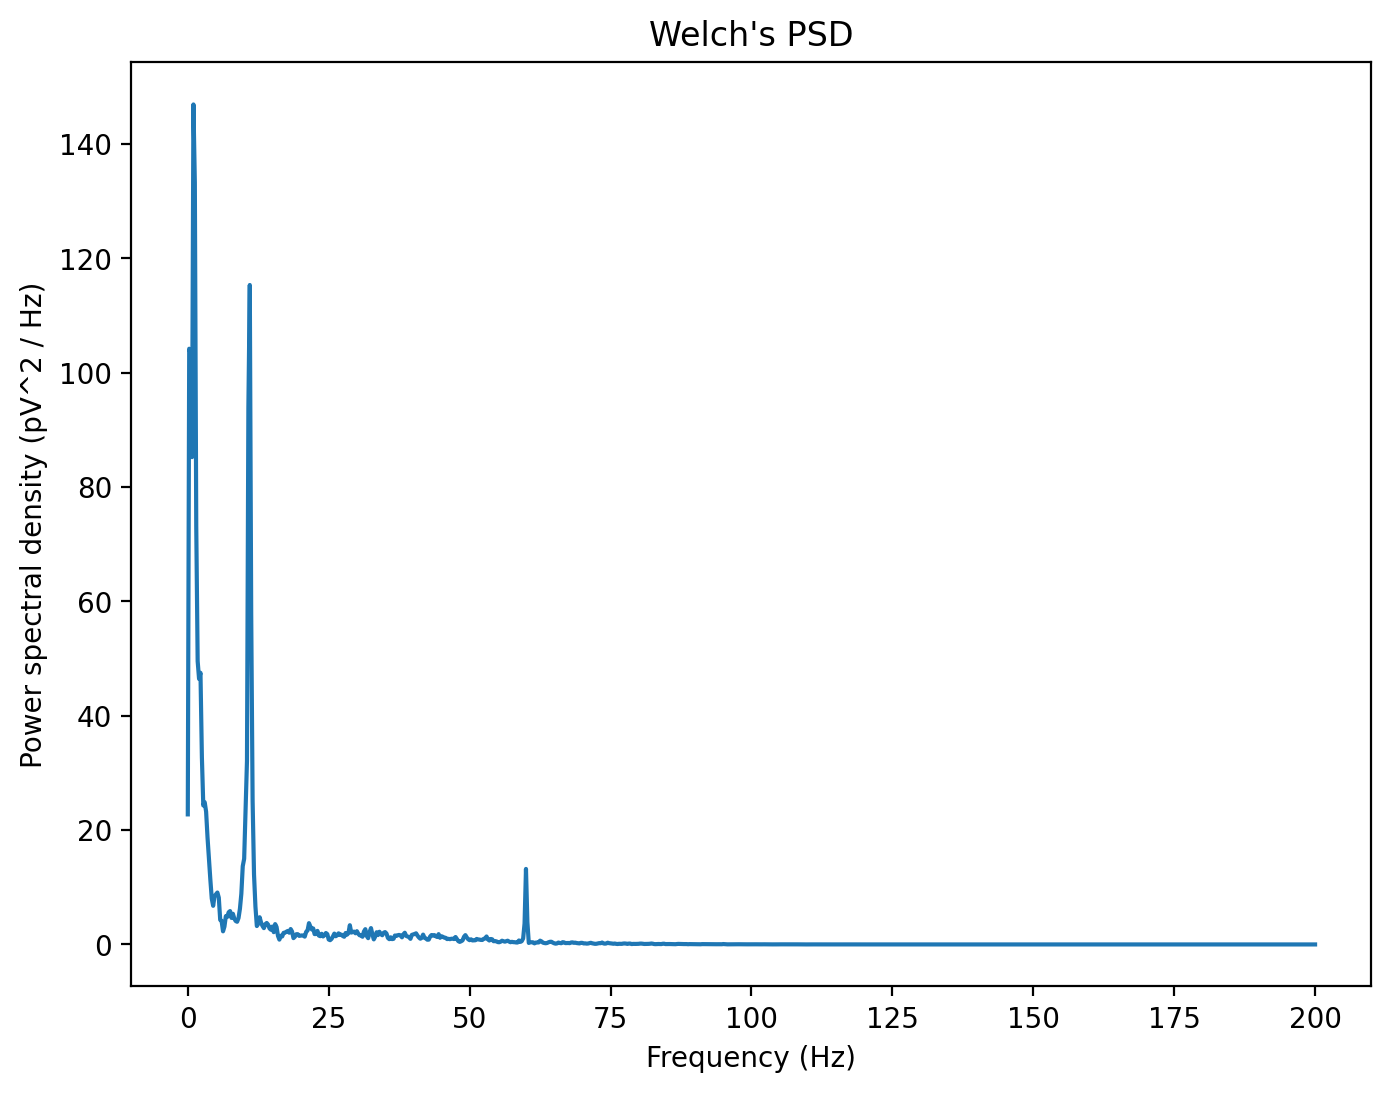

In [8]:
from scipy import signal

# Define sliding window length (4 seconds, which will give us 2 full cycles at 0.5 Hz)
win = 4 * sampling_freq
freqs, psd = signal.welch(closed_recording, sampling_freq, nperseg=win)

# Plot the power spectrum
plt.figure(figsize=(8, 6))
plt.plot(freqs, psd)

# Uncomment the lines below to plot two lines
#open_freqs, open_psd = signal.welch(open_recording, sampling_freq, nperseg=win)
#plt.plot(open_freqs, open_psd)
#plt.legend(['Closed','Open'])

plt.xlabel('Frequency (Hz)')
plt.ylabel('Power spectral density (pV^2 / Hz)') # Check that these units make sense!
#plt.xlim([0,75]) # Change x limit

plt.title("Welch's PSD")
plt.savefig('welch.png', dpi =300)
plt.show()

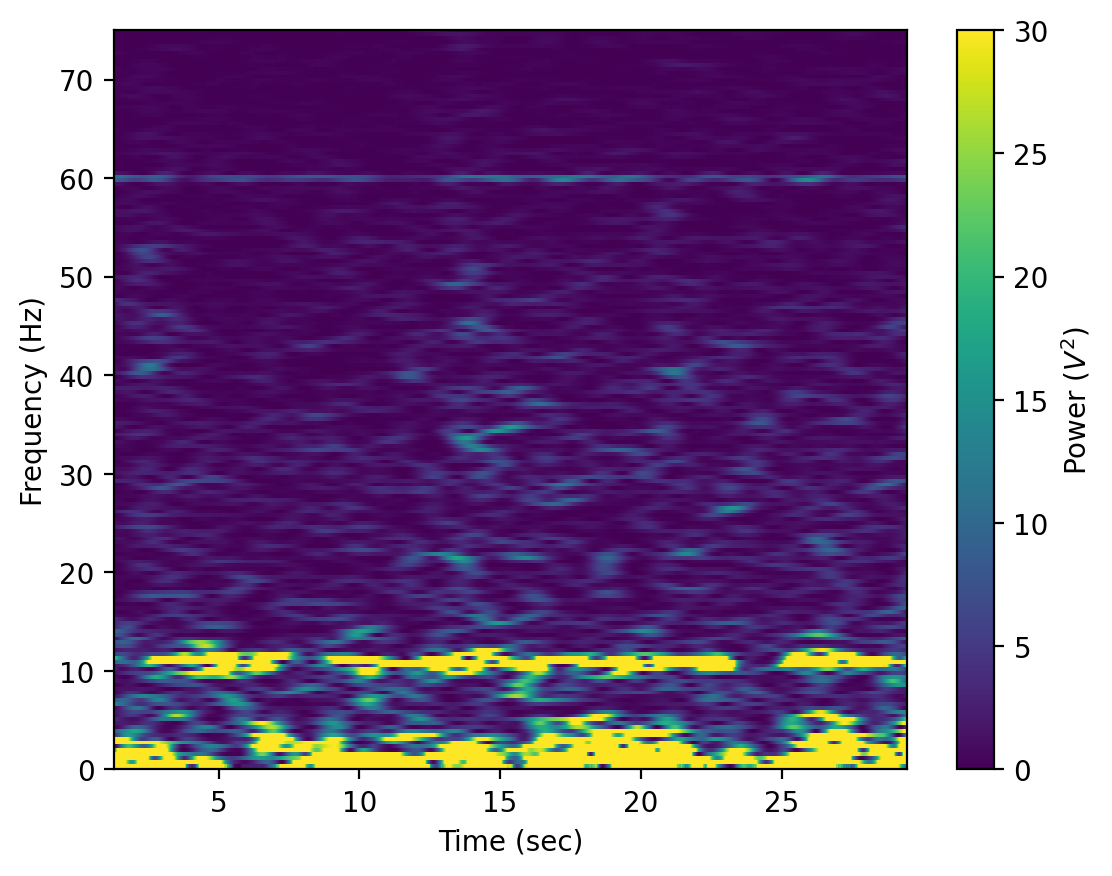

In [17]:
vmax = 30 # change the max value on your spectogram -- you may need to adjust this

wind = np.hanning(1024) # Create a "hanning" window with a given binning window size

# Create the spectrogram and plot
fig = plt.figure() 

# Change closed to open below to generate for open
f, tt, Sxx = signal.spectrogram(closed_recording,sampling_freq,wind,len(wind),len(wind)-1)

# You can change cmap & vmax if you want
plt.pcolormesh(tt,f,Sxx,cmap='viridis',vmax=vmax)
plt.ylabel('Frequency (Hz)')
plt.xlabel('Time (sec)')
plt.ylim([0,75]) # set the ylimit
cbar = plt.colorbar()
cbar.ax.set_ylabel('Power ($V^2$)')
plt.savefig('spectrogram.png', dpi =300)
plt.show()